In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
import scipy
import pandas as pd
import segyio

In [8]:
data_folder = '2026seisham'

for fpath in sorted(glob.glob(os.path.join(data_folder, '*.sgy'))):
    with segyio.open(fpath, ignore_geometry=True) as f:
        
        # Seismic data: shape (n_traces, n_samples) → transpose to (n_samples, n_traces)
        seismic = segyio.tools.collect(f.trace[:]).T
        
        # Time step in ms (SEG-Y stores dt in microseconds)
        dt = segyio.tools.dt(f) / 1000.0
        
        # Per-trace receiver positions from trace headers
        rx = np.array([f.header[i][segyio.TraceField.GroupX] for i in range(f.tracecount)], dtype=float)
        rz = np.array([f.header[i][segyio.TraceField.GroupWaterDepth] for i in range(f.tracecount)], dtype=float)
        
        # Single source position (same for all traces in one shot gather)
        sx = float(f.header[0][segyio.TraceField.SourceX])
        sz = float(f.header[0][segyio.TraceField.SourceDepth])
        
        print(f"{os.path.basename(fpath)}: seismic={seismic.shape}, dt={dt}ms, sx={sx}, sz={sz}")

1.sgy: seismic=(2000, 24), dt=0.5ms, sx=100.0, sz=0.0
10.sgy: seismic=(2000, 24), dt=0.5ms, sx=10.0, sz=0.0
11.sgy: seismic=(2000, 24), dt=0.5ms, sx=5.0, sz=0.0
12.sgy: seismic=(2000, 24), dt=0.5ms, sx=5.0, sz=0.0
13.sgy: seismic=(2000, 24), dt=0.5ms, sx=40.0, sz=0.0
14.sgy: seismic=(2000, 24), dt=0.5ms, sx=41.0, sz=0.0
15.sgy: seismic=(2000, 24), dt=0.5ms, sx=42.0, sz=0.0
16.sgy: seismic=(2000, 24), dt=0.5ms, sx=43.0, sz=0.0
17.sgy: seismic=(2000, 24), dt=0.5ms, sx=44.0, sz=0.0
18.sgy: seismic=(2000, 24), dt=0.5ms, sx=45.0, sz=0.0
19.sgy: seismic=(2000, 24), dt=0.5ms, sx=46.0, sz=0.0
2.sgy: seismic=(2000, 24), dt=0.5ms, sx=90.0, sz=0.0
20.sgy: seismic=(2000, 24), dt=0.5ms, sx=47.0, sz=0.0
21.sgy: seismic=(2000, 24), dt=0.5ms, sx=48.0, sz=0.0
22.sgy: seismic=(2000, 24), dt=0.5ms, sx=49.0, sz=0.0
23.sgy: seismic=(2000, 24), dt=0.5ms, sx=50.0, sz=0.0
24.sgy: seismic=(2000, 24), dt=0.5ms, sx=51.0, sz=0.0
25.sgy: seismic=(2000, 24), dt=0.5ms, sx=52.0, sz=0.0
26.sgy: seismic=(2000, 24), dt=

In [12]:
with segyio.open(fpath, ignore_geometry=True) as f:
    print(f.header[0])  # prints all header fields for the first trace

{TRACE_SEQUENCE_LINE: 0, TRACE_SEQUENCE_FILE: 0, FieldRecord: 9, TraceNumber: 1, EnergySourcePoint: 0, CDP: 0, CDP_TRACE: 0, TraceIdentificationCode: 1, NSummedTraces: 3, NStackedTraces: 3, DataUse: 0, offset: 0, ReceiverGroupElevation: 0, SourceSurfaceElevation: 0, SourceDepth: 0, ReceiverDatumElevation: 0, SourceDatumElevation: 0, SourceWaterDepth: 0, GroupWaterDepth: 0, ElevationScalar: 0, SourceGroupScalar: 1, SourceX: 20, SourceY: 0, GroupX: 0, GroupY: 0, CoordinateUnits: 1, WeatheringVelocity: 0, SubWeatheringVelocity: 0, SourceUpholeTime: 0, GroupUpholeTime: 0, SourceStaticCorrection: 0, GroupStaticCorrection: 0, TotalStaticApplied: 0, LagTimeA: 0, LagTimeB: 0, DelayRecordingTime: 0, MuteTimeStart: 0, MuteTimeEND: 0, TRACE_SAMPLE_COUNT: 2000, TRACE_SAMPLE_INTERVAL: 500, GainType: 0, InstrumentGainConstant: 0, InstrumentInitialGain: 0, Correlated: 0, SweepFrequencyStart: 0, SweepFrequencyEnd: 0, SweepLength: 0, SweepType: 0, SweepTraceTaperLengthStart: 0, SweepTraceTaperLengthEnd

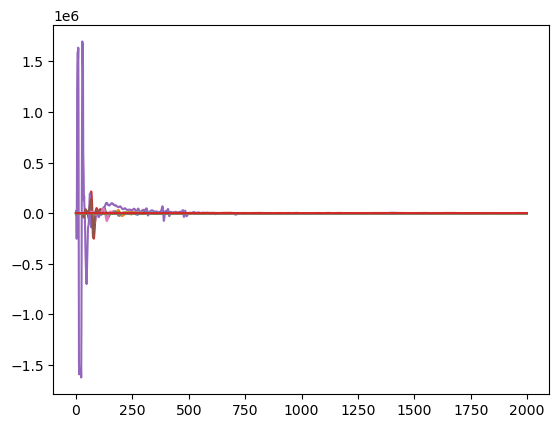

In [13]:
plt.plot(seismic)

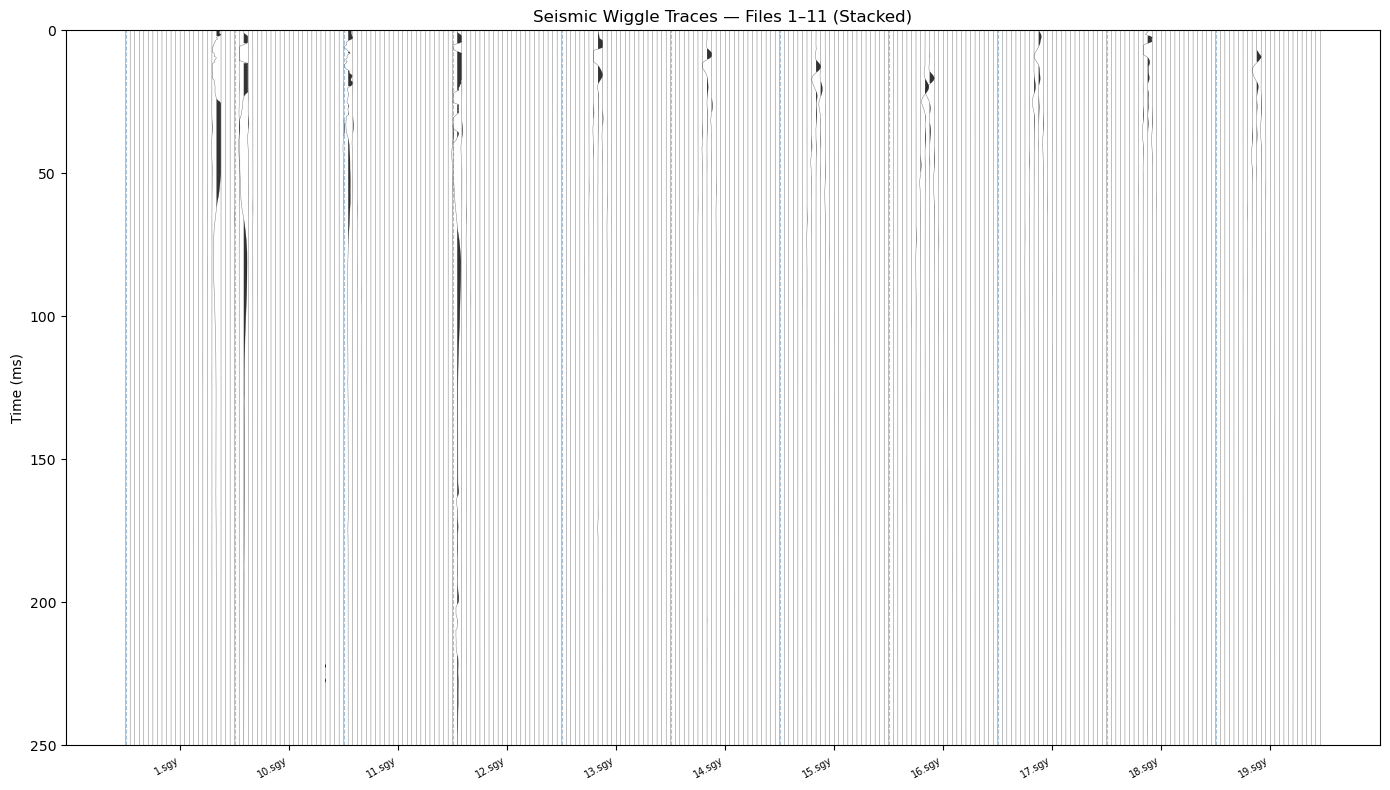

In [19]:
fpaths = sorted(glob.glob(os.path.join(data_folder, '*.sgy')))[:11]

fig, ax = plt.subplots(figsize=(14, 8))

all_traces = []
all_times  = []
trace_offset = 0
xtick_pos, xtick_labels = [], []

for file_idx, fpath in enumerate(fpaths):
    with segyio.open(fpath, ignore_geometry=True) as f:
        seismic = segyio.tools.collect(f.trace[:]).T   # (n_samples, n_traces)
        dt      = segyio.tools.dt(f) / 1000.0
        n_samples, n_traces = seismic.shape
        time    = np.arange(n_samples) * dt

        scale = np.max(np.abs(seismic)) or 1.0

        for i in range(n_traces):
            x = trace_offset + i + seismic[:, i] / scale
            ax.fill_betweenx(time, trace_offset + i, x, where=(seismic[:, i] > 0),
                             color='k', lw=0, alpha=0.8)
            ax.plot(x, time, 'k', lw=0.3, alpha=0.6)

        # Mark the centre of each file's traces
        mid = trace_offset + n_traces / 2
        xtick_pos.append(mid)
        xtick_labels.append(os.path.basename(fpath))

        # Divider between files
        ax.axvline(trace_offset, color='steelblue', lw=0.8, ls='--', alpha=0.5)

        trace_offset += n_traces
    ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=7)
ax.set_ylabel('Time (ms)')
ax.set_title('Seismic Wiggle Traces — Files 1–11 (Stacked)', fontsize=12)
ax.set_ylim(0, 250)
ax.invert_yaxis()
plt.tight_layout()
plt.show()